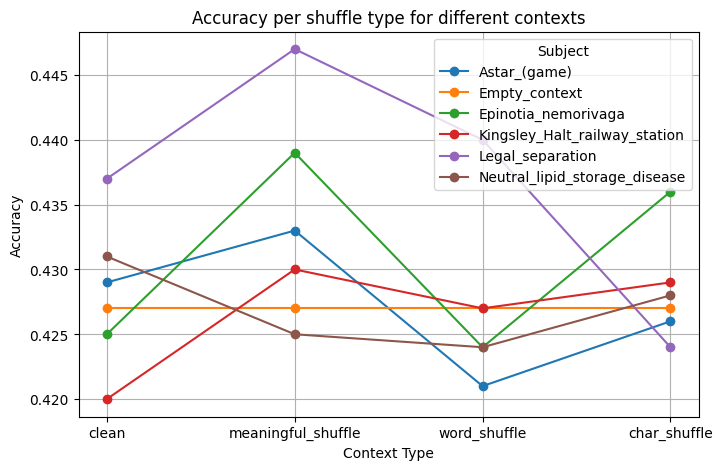

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results.csv")
df = df.tail(24)

order = ["clean", "meaningful_shuffle", "word_shuffle", "char_shuffle"]
df["context_type"] = pd.Categorical(df["context_type"], categories=order, ordered=True)

plt.figure(figsize=(8,5))

for subject, group in df.groupby("context_title"):
    group = group.sort_values("context_type")
    plt.plot(group["context_type"], group["accuracy"], marker='o', label=subject)

plt.title("Accuracy per shuffle type for different contexts")
plt.xlabel("Context type")
plt.ylabel("Accuracy")
plt.legend(title="Subject")
plt.grid(True)
plt.show()




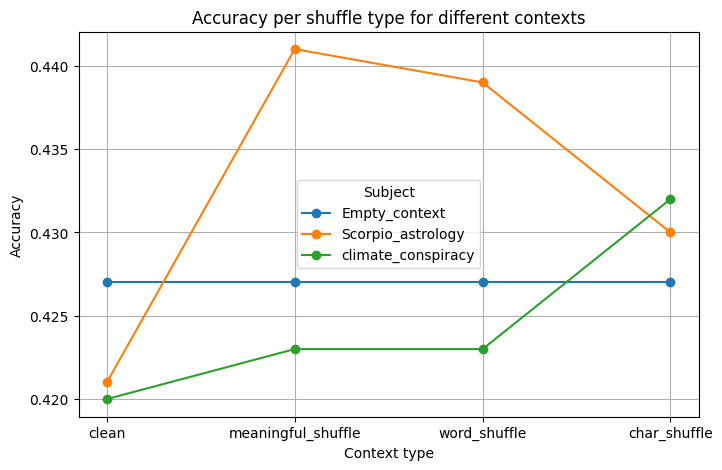

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results.csv")

subjects_to_plot = ["Scorpio_astrology", "climate_conspiracy", "Empty_context"]
df = df[df["context_title"].isin(subjects_to_plot)]

order = ["clean", "meaningful_shuffle", "word_shuffle", "char_shuffle"]
df["context_type"] = pd.Categorical(df["context_type"], categories=order, ordered=True)

plt.figure(figsize=(8,5))

for subject, group in df.groupby("context_title"):
    group = group.sort_values("context_type")
    plt.plot(group["context_type"], group["accuracy"], marker='o', label=subject)

plt.title("Accuracy per shuffle type for different contexts")
plt.xlabel("Context type")
plt.ylabel("Accuracy")
plt.legend(title="Subject")
plt.grid(True)
plt.show()


/tmp/ipykernel_105599/4093788812.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


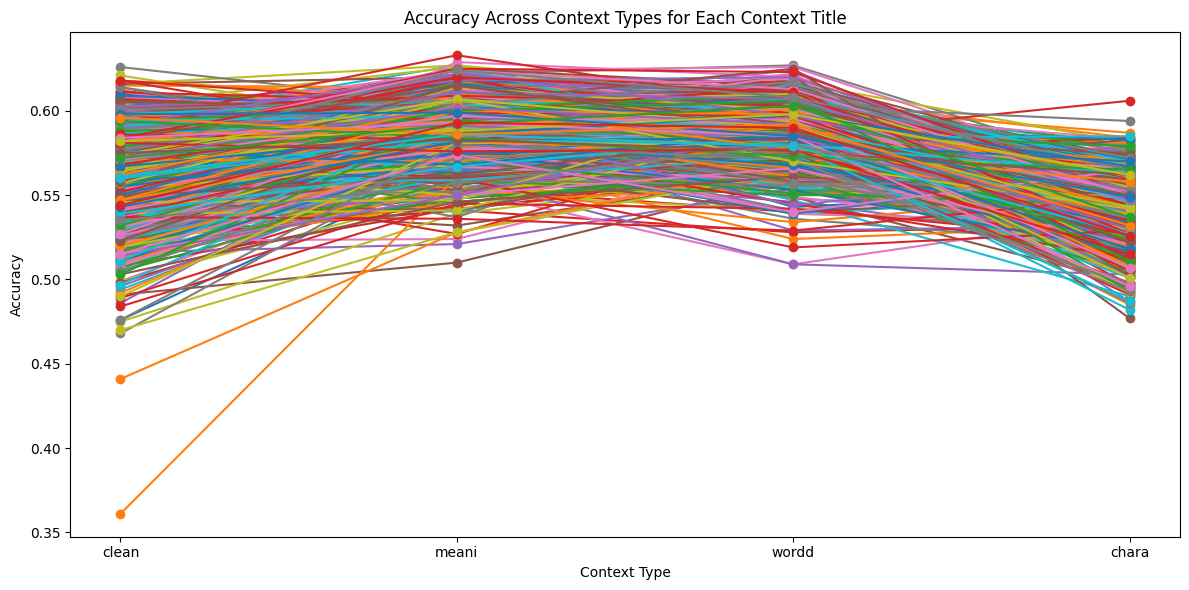

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results_wikipedia.csv")
context_order = ["clean", "meani", "wordd", "chara"]
df["context_type"] = pd.Categorical(df["context_type"], categories=context_order, ordered=True)

pivot = df.pivot_table(
    index="context_title",
    columns="context_type",
    values="accuracy"
).reindex(columns=context_order)

plt.figure(figsize=(12, 6))

for context_title in pivot.index:
    plt.plot(context_order, pivot.loc[context_title], marker="o", label=context_title)

plt.xlabel("Context Type")
plt.ylabel("Accuracy")
plt.title("Accuracy Across Context Types for Each Context Title")
plt.tight_layout()
plt.show()


/tmp/ipykernel_3297862/490305750.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["model_name", "context_type"])["accuracy"]
/tmp/ipykernel_3297862/490305750.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["model_name", "context_type"])["accuracy"]
/tmp/ipykernel_3297862/490305750.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["model_name", "context_type"])["accuracy"]
/

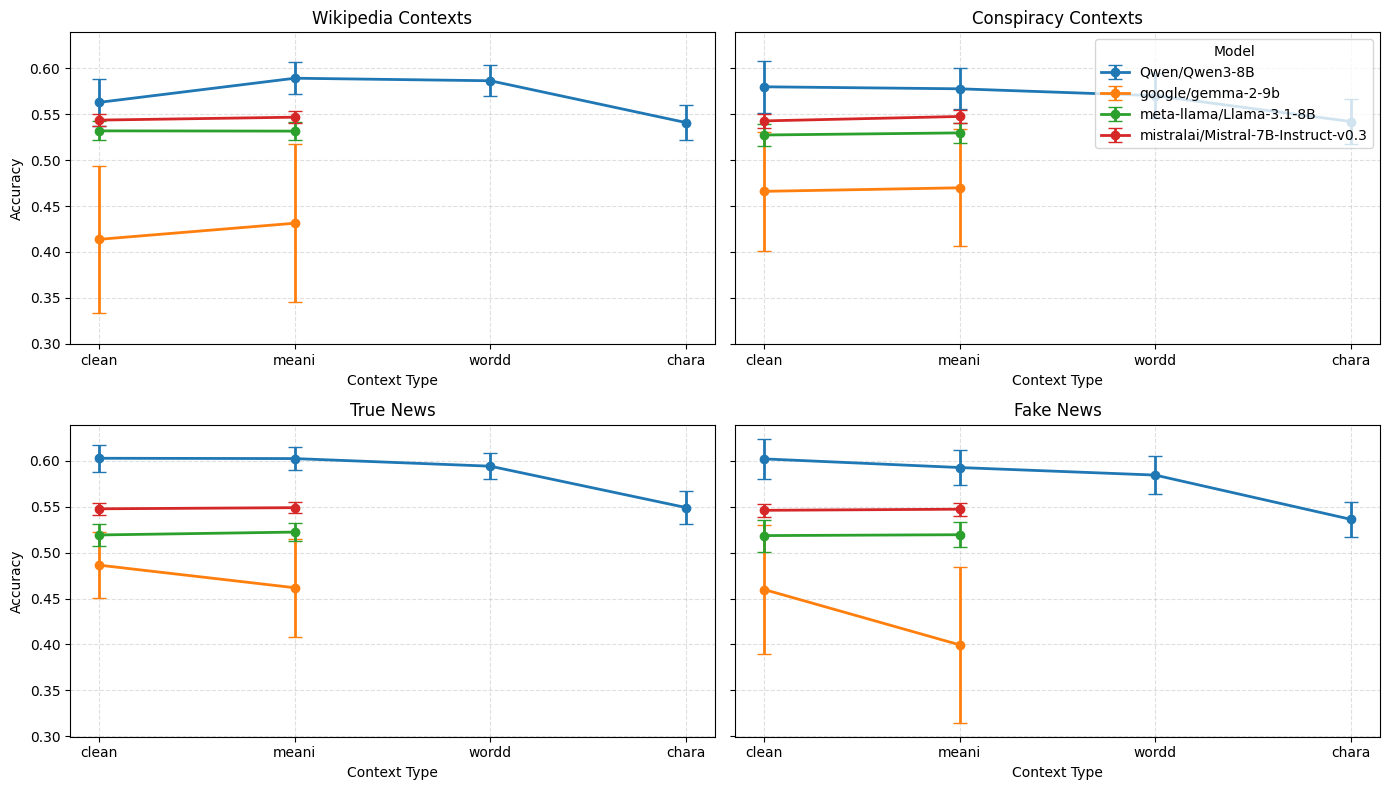

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

csv_files = [
    "results_wikipedia.csv",
    "results_conspiracy.csv",
    "results_isot_true_temporally.csv",
    "results_isot_fake.csv"
]

dfs = [pd.read_csv(f) for f in csv_files]

context_order = ["clean", "meani", "wordd", "chara"]

for df in dfs:
    df["context_type"] = pd.Categorical(df["context_type"], categories=context_order, ordered=True)

def compute_stats(df):
    return (
        df.groupby(["model_name", "context_type"])["accuracy"]
          .agg(["mean", "std"])
          .reset_index()
    )

stats_list = [compute_stats(df) for df in dfs]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
axes = axes.flatten()

titles = ["Wikipedia Contexts", "Conspiracy Contexts", "True News", "Fake News"]

for ax, stats, title in zip(axes, stats_list, titles):
    for model_name, model_df in stats.groupby("model_name"):
        model_df = model_df.set_index("context_type").reindex(context_order).reset_index()
        ax.errorbar(
            x=model_df["context_type"],
            y=model_df["mean"],
            yerr=model_df["std"],
            marker="o",
            capsize=5,
            linewidth=2,
            label=model_name
        )
    ax.set_xlabel("Context Type")
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.4)

axes[0].set_ylabel("Accuracy")
axes[2].set_ylabel("Accuracy")
axes[1].legend(title="Model", loc="upper right")
plt.tight_layout()
plt.show()



/tmp/ipykernel_1000280/4005188595.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["model_name", "context_type"])["accuracy"]
/tmp/ipykernel_1000280/4005188595.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["model_name", "context_type"])["accuracy"]
/tmp/ipykernel_1000280/4005188595.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["model_name", "context_type"])["accuracy"

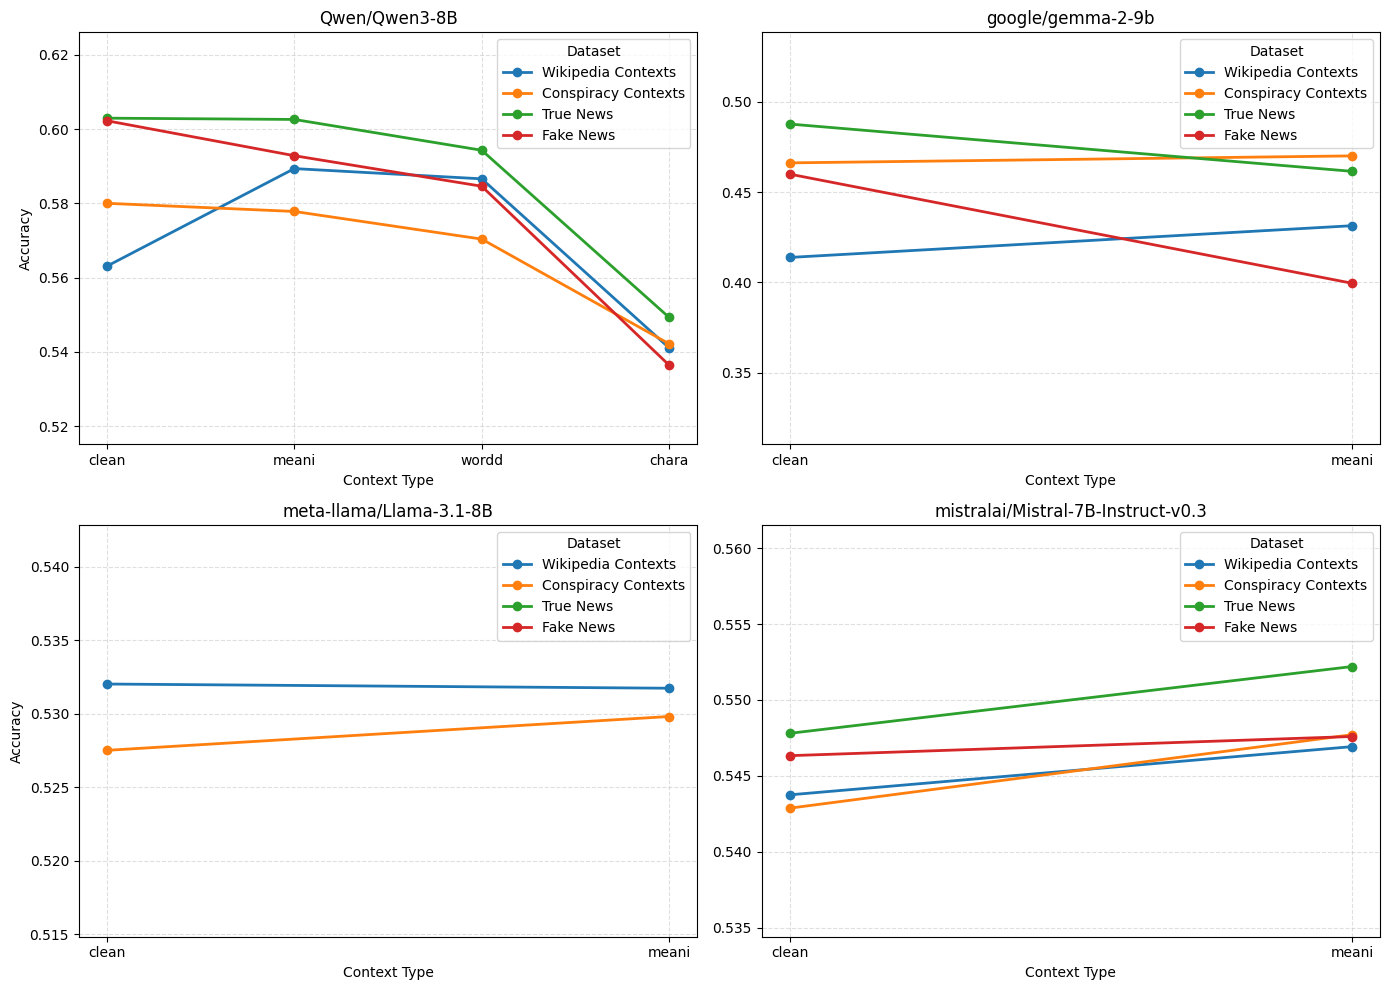

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

csv_files = [
    "results_wikipedia.csv",
    "results_conspiracy.csv",
    "results_isot_true.csv",
    "results_isot_fake.csv"
]

dfs = [pd.read_csv(f) for f in csv_files]
dataset_names = ["Wikipedia Contexts", "Conspiracy Contexts", "True News", "Fake News"]

context_order = ["clean", "meani", "wordd", "chara"]

for df in dfs:
    df["context_type"] = pd.Categorical(df["context_type"], categories=context_order, ordered=True)

def compute_stats(df):
    return (
        df.groupby(["model_name", "context_type"])["accuracy"]
          .agg(["mean", "std"])
          .reset_index()
    )

stats_list = [compute_stats(df) for df in dfs]

all_models = sorted(set().union(*(stats["model_name"].unique() for stats in stats_list)))
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = plt.cm.tab10.colors

for ax, model_name in zip(axes, all_models):
    y_min, y_max = float('inf'), float('-inf')
    for i, (stats, dataset_name) in enumerate(zip(stats_list, dataset_names)):
        model_df = stats[stats["model_name"] == model_name].set_index("context_type").reindex(context_order).reset_index()
        ax.errorbar(
            x=model_df["context_type"],
            y=model_df["mean"],
            #yerr=model_df["std"],
            marker="o",
            capsize=5,
            linewidth=2,
            label=dataset_name,
            color=colors[i % len(colors)]
        )

        current_min = (model_df["mean"] - model_df["std"]).min()
        current_max = (model_df["mean"] + model_df["std"]).max()
        y_min = min(y_min, current_min)
        y_max = max(y_max, current_max)
    
    margin = 0.02  
    y_range = y_max - y_min
    ax.set_ylim(y_min - margin * y_range, y_max + margin * y_range)
    
    ax.set_xlabel("Context Type")
    ax.set_title(model_name)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(title="Dataset")

axes[0].set_ylabel("Accuracy")
axes[2].set_ylabel("Accuracy")
plt.tight_layout()
plt.show()


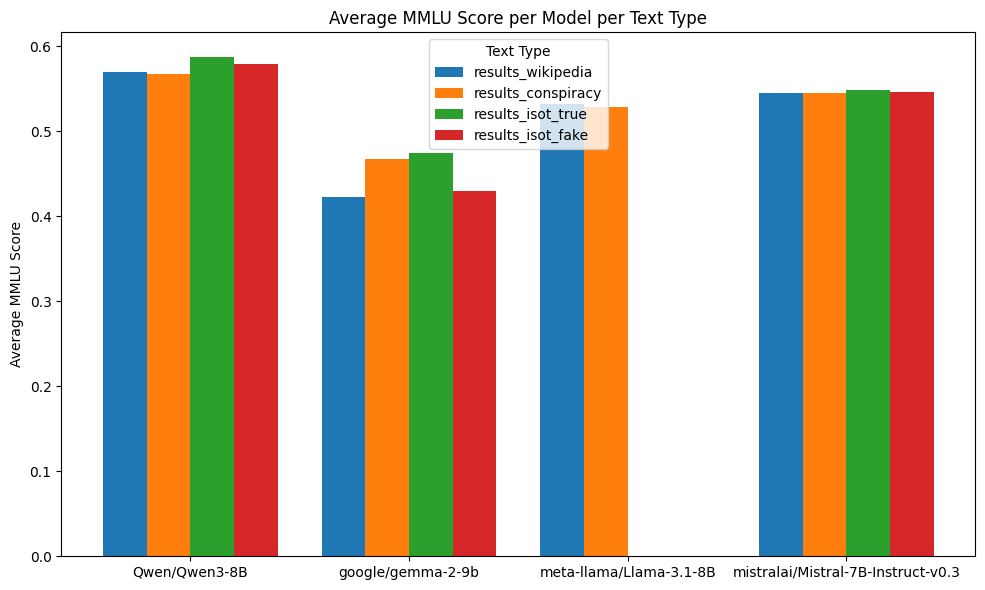

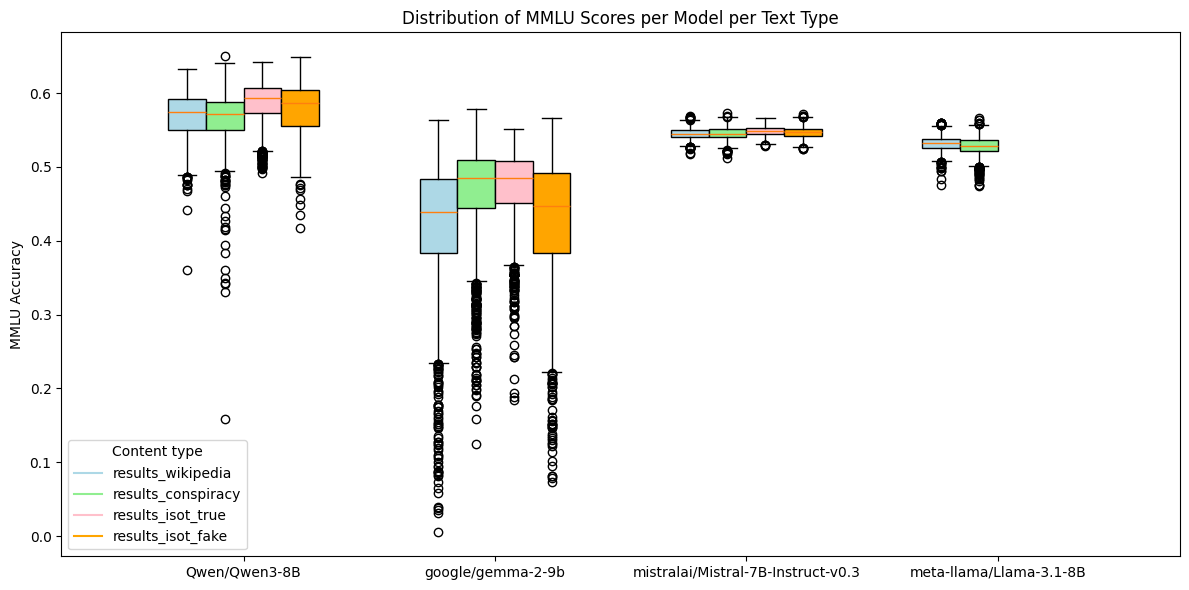

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import glob


csv_files = ["results_wikipedia.csv", "results_conspiracy.csv", "results_isot_true.csv", "results_isot_fake.csv"]

dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    text_type = file.replace(".csv", "")
    df['text_type'] = text_type
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
order = [
    "results_wikipedia",
    "results_conspiracy",
    "results_isot_true",
    "results_isot_fake"
]

avg_scores = data.groupby(['model_name', 'text_type'])['accuracy'].mean().unstack()
avg_scores = avg_scores[order]

fig, ax = plt.subplots(figsize=(10,6))

models = avg_scores.index
x = range(len(models))
width = 0.2  

for i, text_type in enumerate(avg_scores.columns):
    ax.bar([p + width*i for p in x], avg_scores[text_type], width, label=text_type)

ax.set_xticks([p + width*(len(avg_scores.columns)/2 - 0.5) for p in x])
ax.set_xticklabels(models)
ax.set_ylabel("Average MMLU Score")
ax.set_title("Average MMLU Score per Model per Text Type")
ax.legend(title="Text Type")
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(12,6))

models_list = data['model_name'].unique()
text_types_list = data['text_type'].unique()
num_models = len(models_list)
num_text_types = len(text_types_list)
width = 0.15  

positions = []
box_data = []

for i, model in enumerate(models_list):
    for j, text_type in enumerate(text_types_list):
        subset = data[(data['model_name'] == model) & (data['text_type'] == text_type)]
        box_data.append(subset['accuracy'].values)
        positions.append(i + j*width)


b = ax.boxplot(box_data, positions=positions, widths=width, patch_artist=True)


colors = ['lightblue', 'lightgreen', 'pink', 'orange']
for patch, color in zip(b['boxes'], colors * num_models):
    patch.set_facecolor(color)

ax.set_xticks([i + width*(num_text_types-1)/2 for i in range(num_models)])
ax.set_xticklabels(models_list)
ax.set_ylabel("MMLU Accuracy")
ax.set_title("Distribution of MMLU Scores per Model per Text Type")

for i, text_type in enumerate(text_types_list):
    ax.plot([], c=colors[i], label=text_type)
ax.legend(title="Content type")
plt.tight_layout()
plt.show()


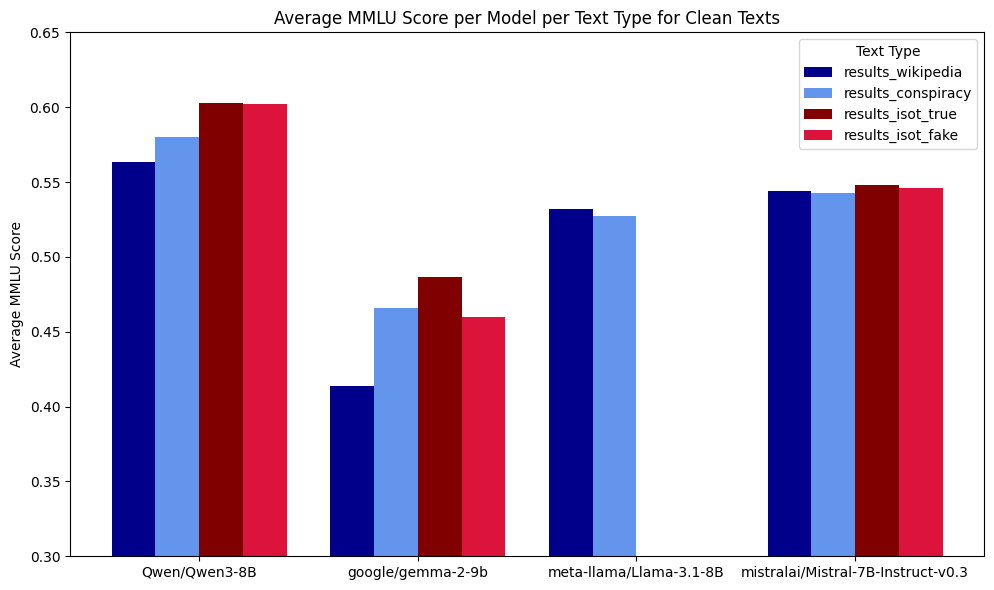

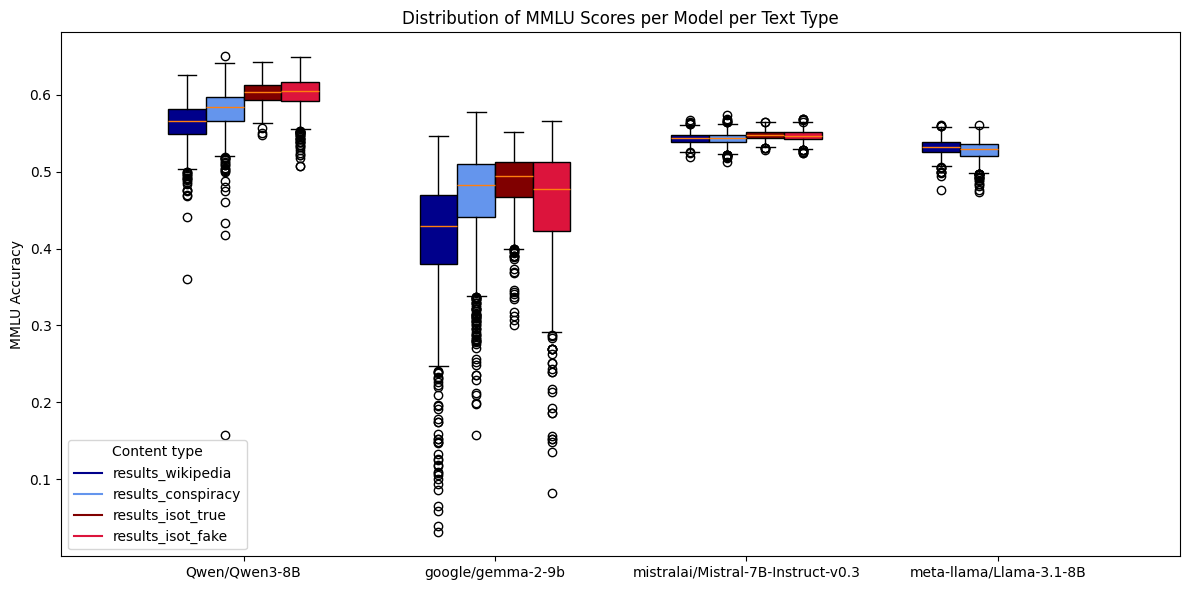

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import glob


csv_files = ["results_wikipedia.csv", "results_conspiracy.csv", "results_isot_true.csv", "results_isot_fake.csv"]
dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    df = df[df['context_type'] == 'clean']

    text_type = file.replace(".csv", "")
    df['text_type'] = text_type
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
order = [
    "results_wikipedia",
    "results_conspiracy",
    "results_isot_true",
    "results_isot_fake"
]
color_list = {
    "results_wikipedia": 'darkblue',
    "results_conspiracy": 'cornflowerblue',
    "results_isot_true": 'maroon',
    "results_isot_fake": 'crimson'
}
avg_scores = data.groupby(['model_name', 'text_type'])['accuracy'].mean().unstack()
avg_scores = avg_scores[order]

fig, ax = plt.subplots(figsize=(10,6))

models = avg_scores.index
x = range(len(models))
width = 0.2  

for i, text_type in enumerate(avg_scores.columns):
    ax.bar([p + width*i for p in x], avg_scores[text_type], width, label=text_type, color=color_list[text_type])

ax.set_xticks([p + width*(len(avg_scores.columns)/2 - 0.5) for p in x])
ax.set_xticklabels(models)
ax.set_ylabel("Average MMLU Score")
ax.set_title("Average MMLU Score per Model per Text Type for Clean Texts")
ax.legend(title="Text Type")
plt.tight_layout()
plt.ylim((0.3,0.65))
plt.show()


fig, ax = plt.subplots(figsize=(12,6))

models_list = data['model_name'].unique()
text_types_list = data['text_type'].unique()
num_models = len(models_list)
num_text_types = len(text_types_list)
width = 0.15  

positions = []
box_data = []

for i, model in enumerate(models_list):
    for j, text_type in enumerate(text_types_list):
        subset = data[(data['model_name'] == model) & (data['text_type'] == text_type)]
        box_data.append(subset['accuracy'].values)
        positions.append(i + j*width)


b = ax.boxplot(box_data, positions=positions, widths=width, patch_artist=True)


colors = ['darkblue', 'cornflowerblue', 'maroon', 'crimson']
for patch, color in zip(b['boxes'], colors * num_models):
    patch.set_facecolor(color)

ax.set_xticks([i + width*(num_text_types-1)/2 for i in range(num_models)])
ax.set_xticklabels(models_list)
ax.set_ylabel("MMLU Accuracy")
ax.set_title("Distribution of MMLU Scores per Model per Text Type")

for i, text_type in enumerate(text_types_list):
    ax.plot([], c=colors[i], label=text_type)
ax.legend(title="Content type")
plt.tight_layout()
plt.show()


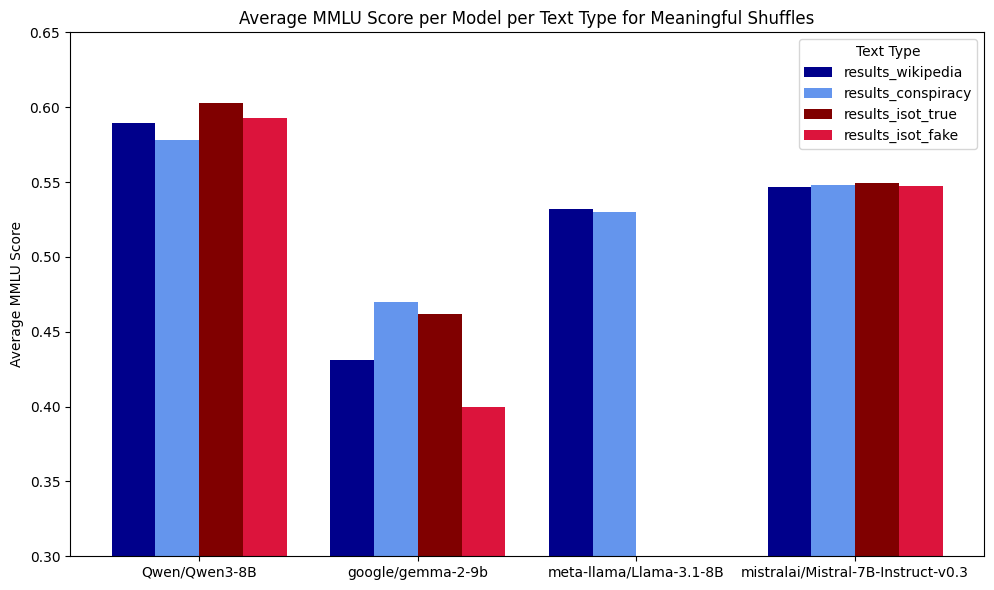

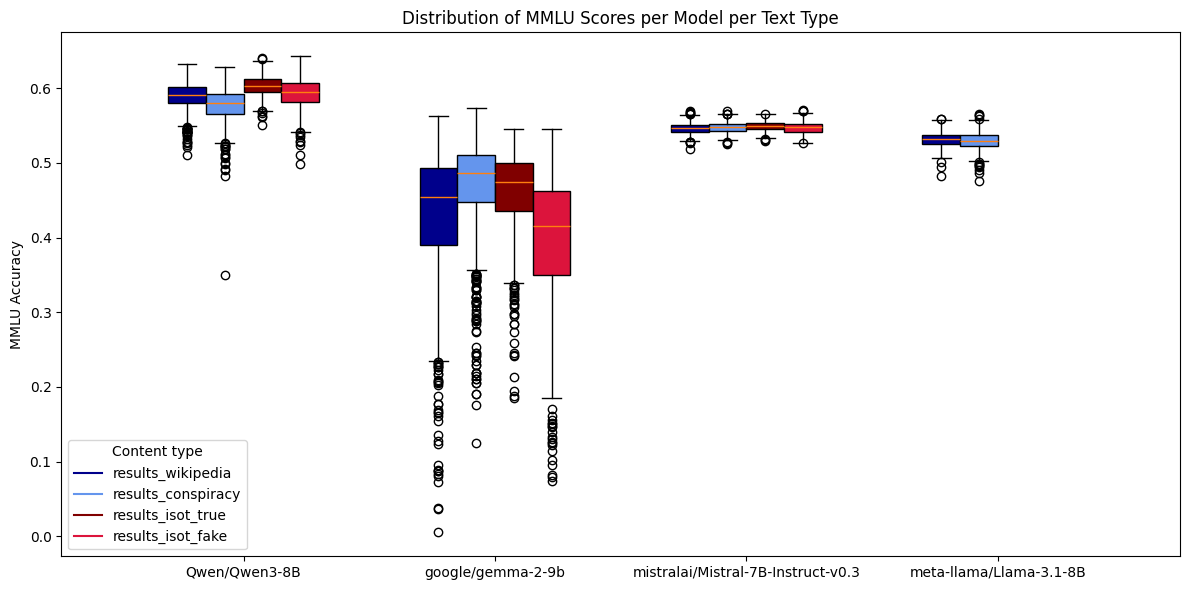

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import glob


csv_files = ["results_wikipedia.csv", "results_conspiracy.csv", "results_isot_true.csv", "results_isot_fake.csv"]
dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    df = df[df['context_type'] == 'meani']

    text_type = file.replace(".csv", "")
    df['text_type'] = text_type
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
order = [
    "results_wikipedia",
    "results_conspiracy",
    "results_isot_true",
    "results_isot_fake"
]
color_list = {
    "results_wikipedia": 'darkblue',
    "results_conspiracy": 'cornflowerblue',
    "results_isot_true": 'maroon',
    "results_isot_fake": 'crimson'
}
avg_scores = data.groupby(['model_name', 'text_type'])['accuracy'].mean().unstack()
avg_scores = avg_scores[order]

fig, ax = plt.subplots(figsize=(10,6))

models = avg_scores.index
x = range(len(models))
width = 0.2  

for i, text_type in enumerate(avg_scores.columns):
    ax.bar([p + width*i for p in x], avg_scores[text_type], width, label=text_type, color=color_list[text_type])

ax.set_xticks([p + width*(len(avg_scores.columns)/2 - 0.5) for p in x])
ax.set_xticklabels(models)
ax.set_ylabel("Average MMLU Score")
ax.set_title("Average MMLU Score per Model per Text Type for Meaningful Shuffles")
ax.legend(title="Text Type")
plt.tight_layout()
plt.ylim((0.3,0.65))
plt.show()


fig, ax = plt.subplots(figsize=(12,6))

models_list = data['model_name'].unique()
text_types_list = data['text_type'].unique()
num_models = len(models_list)
num_text_types = len(text_types_list)
width = 0.15  

positions = []
box_data = []

for i, model in enumerate(models_list):
    for j, text_type in enumerate(text_types_list):
        subset = data[(data['model_name'] == model) & (data['text_type'] == text_type)]
        box_data.append(subset['accuracy'].values)
        positions.append(i + j*width)


b = ax.boxplot(box_data, positions=positions, widths=width, patch_artist=True)


colors = ['darkblue', 'cornflowerblue', 'maroon', 'crimson']
for patch, color in zip(b['boxes'], colors * num_models):
    patch.set_facecolor(color)

ax.set_xticks([i + width*(num_text_types-1)/2 for i in range(num_models)])
ax.set_xticklabels(models_list)
ax.set_ylabel("MMLU Accuracy")
ax.set_title("Distribution of MMLU Scores per Model per Text Type")

for i, text_type in enumerate(text_types_list):
    ax.plot([], c=colors[i], label=text_type)
ax.legend(title="Content type")
plt.tight_layout()
plt.show()


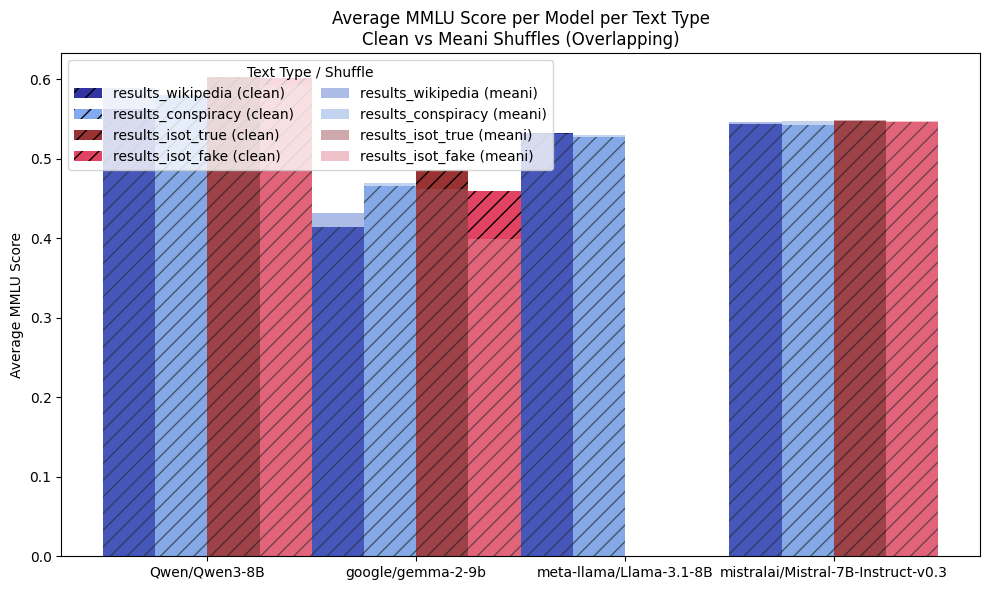

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

csv_files = ["results_wikipedia.csv", "results_conspiracy.csv", "results_isot_true.csv", "results_isot_fake.csv"]

order = [
    "results_wikipedia",
    "results_conspiracy",
    "results_isot_true",
    "results_isot_fake"
]

base_colors = {
    "results_wikipedia": 'darkblue',
    "results_conspiracy": 'cornflowerblue',
    "results_isot_true": 'maroon',
    "results_isot_fake": 'crimson'
}

lighter_colors = {
    "results_wikipedia": '#5a7bd1',
    "results_conspiracy": '#87a9e0',
    "results_isot_true": '#a1525c',
    "results_isot_fake": '#e08592'
}

def load_data(context_type):
    dfs = []
    for file in csv_files:
        df = pd.read_csv(file)
        df = df[df['context_type'] == context_type]
        text_type = file.replace(".csv", "")
        df['text_type'] = text_type
        dfs.append(df)
    data = pd.concat(dfs, ignore_index=True)
    avg_scores = data.groupby(['model_name', 'text_type'])['accuracy'].mean().unstack()
    avg_scores = avg_scores[order]
    return avg_scores

avg_clean = load_data('clean')
avg_meani = load_data('meani')

fig, ax = plt.subplots(figsize=(10,6))
models = avg_clean.index
x = range(len(models))
width = 0.25

for i, text_type in enumerate(avg_clean.columns):
    ax.bar([p + width*i for p in x], avg_clean[text_type], width, 
           label=f"{text_type} (clean)", color=base_colors[text_type], alpha=0.8, hatch='//')

for i, text_type in enumerate(avg_meani.columns):
    ax.bar([p + width*i for p in x], avg_meani[text_type], width, 
           label=f"{text_type} (meani)", color=lighter_colors[text_type], alpha=0.5)

ax.set_xticks([p + width*(len(avg_clean.columns)/2 - 0.5) for p in x])
ax.set_xticklabels(models)
ax.set_ylabel("Average MMLU Score")
ax.set_title("Average MMLU Score per Model per Text Type\nClean vs Meani Shuffles (Overlapping)")

ax.legend(title="Text Type / Shuffle", ncol=2)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

csv_files = ["results_wikipedia.csv", "results_conspiracy.csv", "results_isot_true.csv", "results_isot_fake.csv"]
dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    df = df[df['context_type'] == 'clean']

    text_type = file.replace("results_", "").replace(".csv", "")
    df['text_type'] = text_type
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

order = [
    "wikipedia",
    "conspiracy",
    "isot_true",
    "isot_fake"
]
color_list = {
    "wikipedia": 'darkblue',
    "conspiracy": 'cornflowerblue',
    "isot_true": 'maroon',
    "isot_fake": 'crimson'
}

avg_scores = data.groupby(['model_name', 'text_type'])['accuracy'].mean().unstack()
avg_scores = avg_scores[order]
fig, ax = plt.subplots(figsize=(10,6))

models_list = data['model_name'].unique()
text_types_list = data['text_type'].unique()
num_models = len(models_list)
num_text_types = len(text_types_list)
width = 0.15  

positions = []
violin_data = []
violin_colors = []


for i, model in enumerate(models_list):
    for j, text_type in enumerate(text_types_list):
        subset = data[(data['model_name'] == model) & (data['text_type'] == text_type)]
        values = subset['accuracy'].values
        if len(values) == 0:
            continue
        violin_data.append(values)
        positions.append(i + j*width)
        violin_colors.append(color_list[text_type])


parts = ax.violinplot(violin_data, positions=positions, widths=width,
                      showmeans=True, showextrema=False)

parts['cmeans'].set_color('white')
parts['cmeans'].set_linewidth(2.5)



for patch, color in zip(parts['bodies'], violin_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.9)
    patch.set_edgecolor('black')

ax.set_xticks([i + width*(num_text_types-1)/2 for i in range(num_models)])
ax.set_xticklabels(models_list)
ax.set_ylabel("MMLU Accuracy")

for i, text_type in enumerate(text_types_list):
    ax.plot([], c=color_list[text_type], label=text_type)
ax.legend(title="Content type")

plt.tight_layout()
plt.show()

iqr = (
    data
    .groupby(['model_name', 'text_type'])['accuracy']
    .quantile([0.25, 0.75])
    .unstack()
)

iqr['iqr'] = iqr[0.75] - iqr[0.25]

print(iqr)



NameError: name 'ax' is not defined

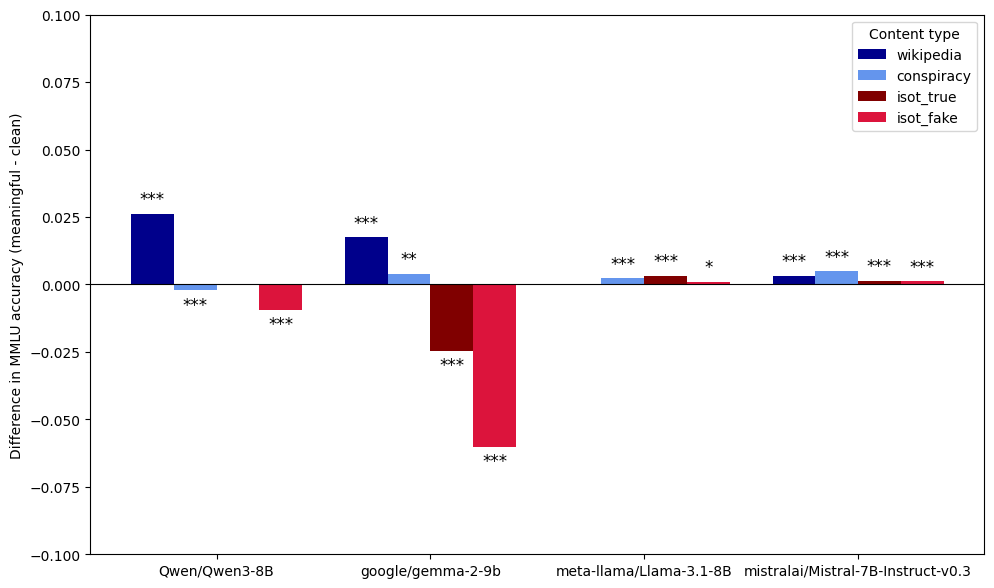

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

csv_files = [
    "results_wikipedia.csv", 
    "results_conspiracy.csv", 
    "results_isot_true.csv", 
    "results_isot_fake.csv"]
dfs_clean = []
dfs_meaningful = []

for file in csv_files:
    text_type = file.replace("results_", "").replace(".csv", "")
    
    df_clean = pd.read_csv(file)
    df_clean = df_clean[df_clean['context_type'] == 'clean']
    df_clean['text_type'] = text_type
    dfs_clean.append(df_clean)
    
    df_meani = pd.read_csv(file)
    df_meani = df_meani[df_meani['context_type'] == 'meani']
    df_meani['text_type'] = text_type
    dfs_meaningful.append(df_meani)

data_clean = pd.concat(dfs_clean, ignore_index=True)
data_meani = pd.concat(dfs_meaningful, ignore_index=True)

order = [
    "wikipedia",
    "conspiracy",
    "isot_true",
    "isot_fake"
]

color_list = {
    "wikipedia": 'darkblue',
    "conspiracy": 'cornflowerblue',
    "isot_true": 'maroon',
    "isot_fake": 'crimson'
}

avg_clean = data_clean.groupby(['model_name', 'text_type'])['accuracy'].mean().unstack()
avg_meani = data_meani.groupby(['model_name', 'text_type'])['accuracy'].mean().unstack()

avg_clean = avg_clean[order]
avg_meani = avg_meani[order]

avg_diff = avg_meani - avg_clean
fig, ax = plt.subplots(figsize=(10,6))

models = avg_diff.index
x = range(len(models))
width = 0.2

for i, text_type in enumerate(avg_diff.columns):
    ax.bar([p + width*i for p in x], avg_diff[text_type], width, label=text_type, color=color_list[text_type])

ax.set_xticks([p + width*(len(avg_diff.columns)/2 - 0.5) for p in x])
ax.set_xticklabels(models)
ax.set_ylabel("Difference in MMLU accuracy (meaningful - clean)")
ax.axhline(0, color='black', linewidth=0.8)
ax.legend(title="Content type")

def add_sig_bar(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, c='black')
    ax.text((x1 + x2)/2, y+h, text, ha='center', va='bottom', fontsize=12)

def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

pvals = {
    ("meta-llama/Llama-3.1-8B", "wikipedia"): 0.5,
    ("meta-llama/Llama-3.1-8B", "conspiracy"): 0.000,
    ("meta-llama/Llama-3.1-8B", "isot_true"): 0.000,
    ("meta-llama/Llama-3.1-8B", "isot_fake"): 0.04,
    
    ("google/gemma-2-9b", "wikipedia"): 0.000,
    ("google/gemma-2-9b", "conspiracy"): 0.009,
    ("google/gemma-2-9b", "isot_true"): 0.000,
    ("google/gemma-2-9b", "isot_fake"): 0.000,
    
    ("Qwen/Qwen3-8B", "wikipedia"): 0.000,
    ("Qwen/Qwen3-8B", "conspiracy"): 0.000,
    ("Qwen/Qwen3-8B", "isot_true"): 0.9,
    ("Qwen/Qwen3-8B", "isot_fake"): 0.000,
    
    ("mistralai/Mistral-7B-Instruct-v0.3", "wikipedia"): 0.000,
    ("mistralai/Mistral-7B-Instruct-v0.3", "conspiracy"): 0.000,
    ("mistralai/Mistral-7B-Instruct-v0.3", "isot_true"): 0.000,
    ("mistralai/Mistral-7B-Instruct-v0.3", "isot_fake"): 0.000,
}


bar_h = 0.005

for i, model in enumerate(models):
    for j, text_type in enumerate(avg_diff.columns):
        difference = avg_diff.loc[model, text_type]
        p = pvals.get((model, text_type), 1)
        star = p_to_star(p)

        if star:
            x = i + j*width
            y = difference + (0.002 if difference >= 0 else -0.002)
            ax.text(
                x, y, star,
                ha='center',
                va='bottom' if difference >= 0 else 'top',
                fontsize=12
            )


        
plt.tight_layout()
plt.ylim((-0.1, 0.1))
plt.show()


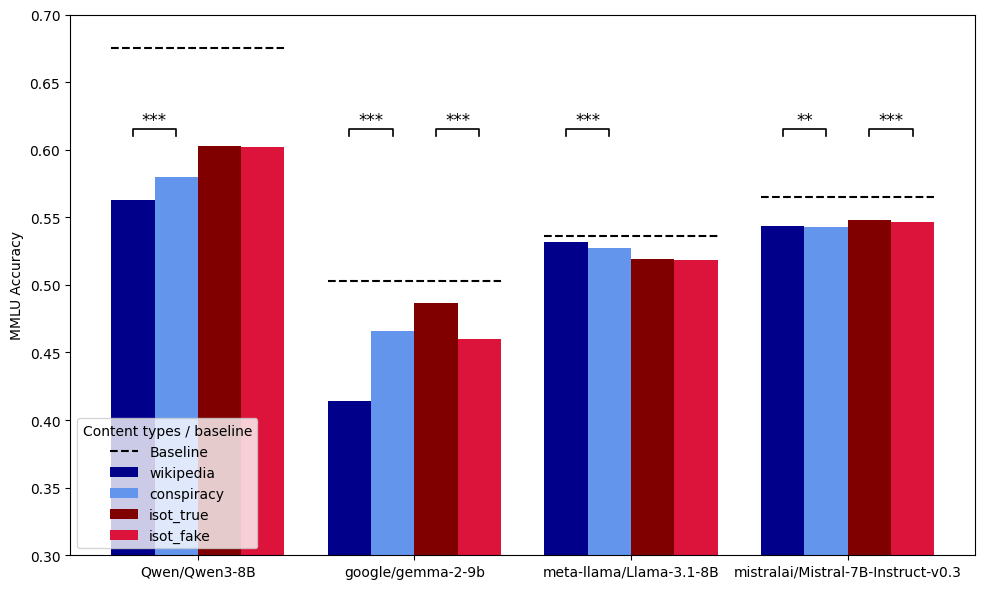

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

csv_files = ["results_wikipedia.csv", "results_conspiracy.csv", "results_isot_true.csv", "results_isot_fake.csv"]
dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    df = df[df['context_type'] == 'clean']

    text_type = file.replace("results_", "").replace(".csv", "")
    df['text_type'] = text_type
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

order = [
    "wikipedia",
    "conspiracy",
    "isot_true",
    "isot_fake"
]

color_list = {
    "wikipedia": 'darkblue',
    "conspiracy": 'cornflowerblue',
    "isot_true": 'maroon',
    "isot_fake": 'crimson'
}

avg_scores = data.groupby(['model_name', 'text_type'])['accuracy'].mean().unstack()
avg_scores = avg_scores[order]


fig, ax = plt.subplots(figsize=(10,6))

models = avg_scores.index
x = range(len(models))
width = 0.2  

for i, text_type in enumerate(avg_scores.columns):
    ax.bar([p + width*i for p in x], avg_scores[text_type], width, label=text_type, color=color_list[text_type])

ax.set_xticks([p + width*(len(avg_scores.columns)/2 - 0.5) for p in x])
ax.set_xticklabels(models)
ax.set_ylabel("MMLU Accuracy")
plt.ylim((0.3, 0.70))

baseline = {
    "meta-llama/Llama-3.1-8B": 0.536,
    "google/gemma-2-9b": 0.503,
    "Qwen/Qwen3-8B": 0.675,
    "mistralai/Mistral-7B-Instruct-v0.3": 0.565
}

line_width = 0.80
for i, model in enumerate(models):
    group_center = i + width*(len(avg_scores.columns)/2 - 0.5)
    label = "Baseline" if i == 0 else "_nolegend_"
    ax.hlines(y=baseline[model],
              xmin=group_center - line_width/2,
              xmax=group_center + line_width/2,
              colors='black',
              linestyles='dashed',
              label=label)

def add_sig_bar(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, c='black')
    ax.text((x1 + x2)/2, y+h, text, ha='center', va='bottom', fontsize=12)

def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

pvals = {
    ("meta-llama/Llama-3.1-8B", "wikipedia_vs_conspiracy"): 0.000,
    ("meta-llama/Llama-3.1-8B", "true_vs_fake"): 0.092,
    ("google/gemma-2-9b", "wikipedia_vs_conspiracy"): 0.000,
    ("google/gemma-2-9b", "true_vs_fake"): 0.000,
    ("Qwen/Qwen3-8B", "wikipedia_vs_conspiracy"): 0.000,
    ("Qwen/Qwen3-8B", "true_vs_fake"): 0.372,
    ("mistralai/Mistral-7B-Instruct-v0.3", "wikipedia_vs_conspiracy"): 0.007,
    ("mistralai/Mistral-7B-Instruct-v0.3", "true_vs_fake"): 0.000
}

bar_h = 0.005

for i, model in enumerate(models):
    base_x = i

    x1 = base_x + 0*width
    x2 = base_x + 1*width
    y = 0.61
    star = p_to_star(pvals.get((model, "wikipedia_vs_conspiracy"), 1))
    if star:
        add_sig_bar(ax, x1, x2, y, bar_h, star)

    x1 = base_x + 2*width
    x2 = base_x + 3*width
    y = 0.61
    star = p_to_star(pvals.get((model, "true_vs_fake"), 1))
    if star:
        add_sig_bar(ax, x1, x2, y, bar_h, star)

ax.legend(title="Content types / baseline")
plt.tight_layout()
plt.show()


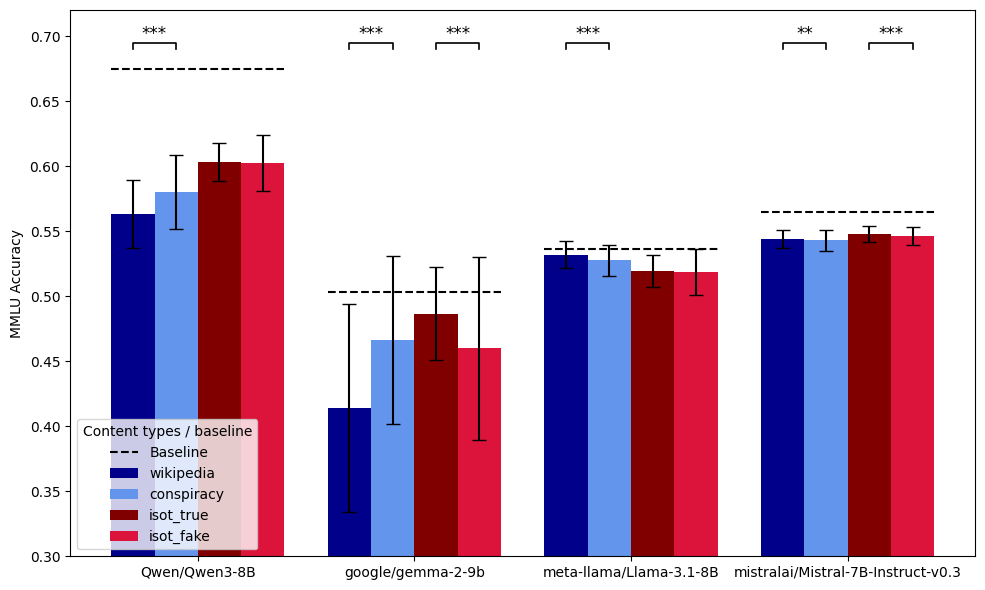

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

csv_files = ["results_wikipedia.csv", "results_conspiracy.csv", "results_isot_true.csv", "results_isot_fake.csv"]
dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    df = df[df['context_type'] == 'clean']

    text_type = file.replace("results_", "").replace(".csv", "")
    df['text_type'] = text_type
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

order = [
    "wikipedia",
    "conspiracy",
    "isot_true",
    "isot_fake"
]

color_list = {
    "wikipedia": 'darkblue',
    "conspiracy": 'cornflowerblue',
    "isot_true": 'maroon',
    "isot_fake": 'crimson'
}

# Calculate mean and standard deviation
avg_scores = data.groupby(['model_name', 'text_type'])['accuracy'].mean().unstack()
avg_scores = avg_scores[order]

std_scores = data.groupby(['model_name', 'text_type'])['accuracy'].std().unstack()
std_scores = std_scores[order]

fig, ax = plt.subplots(figsize=(10,6))

models = avg_scores.index
x = range(len(models))
width = 0.2  

for i, text_type in enumerate(avg_scores.columns):
    ax.bar(
        [p + width*i for p in x], 
        avg_scores[text_type], 
        width, 
        yerr=std_scores[text_type],      # <-- Add standard deviations here
        capsize=5,                       # nice little caps on error bars
        label=text_type, 
        color=color_list[text_type]
    )

ax.set_xticks([p + width*(len(avg_scores.columns)/2 - 0.5) for p in x])
ax.set_xticklabels(models)
ax.set_ylabel("MMLU Accuracy")
plt.ylim((0.30, 0.72))

baseline = {
    "meta-llama/Llama-3.1-8B": 0.536,
    "google/gemma-2-9b": 0.503,
    "Qwen/Qwen3-8B": 0.675,
    "mistralai/Mistral-7B-Instruct-v0.3": 0.565
}

line_width = 0.80
for i, model in enumerate(models):
    group_center = i + width*(len(avg_scores.columns)/2 - 0.5)
    label = "Baseline" if i == 0 else "_nolegend_"
    ax.hlines(y=baseline[model],
              xmin=group_center - line_width/2,
              xmax=group_center + line_width/2,
              colors='black',
              linestyles='dashed',
              label=label)

def add_sig_bar(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, c='black')
    ax.text((x1 + x2)/2, y+h, text, ha='center', va='bottom', fontsize=12)

def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

pvals = {
    ("meta-llama/Llama-3.1-8B", "wikipedia_vs_conspiracy"): 0.000,
    ("meta-llama/Llama-3.1-8B", "true_vs_fake"): 0.092,
    ("google/gemma-2-9b", "wikipedia_vs_conspiracy"): 0.000,
    ("google/gemma-2-9b", "true_vs_fake"): 0.000,
    ("Qwen/Qwen3-8B", "wikipedia_vs_conspiracy"): 0.000,
    ("Qwen/Qwen3-8B", "true_vs_fake"): 0.372,
    ("mistralai/Mistral-7B-Instruct-v0.3", "wikipedia_vs_conspiracy"): 0.007,
    ("mistralai/Mistral-7B-Instruct-v0.3", "true_vs_fake"): 0.000
}

bar_h = 0.005

for i, model in enumerate(models):
    base_x = i

    x1 = base_x + 0*width
    x2 = base_x + 1*width
    y = 0.69
    star = p_to_star(pvals.get((model, "wikipedia_vs_conspiracy"), 1))
    if star:
        add_sig_bar(ax, x1, x2, y, bar_h, star)

    x1 = base_x + 2*width
    x2 = base_x + 3*width
    y = 0.69
    star = p_to_star(pvals.get((model, "true_vs_fake"), 1))
    if star:
        add_sig_bar(ax, x1, x2, y, bar_h, star)

ax.legend(title="Content types / baseline")
plt.tight_layout()
plt.show()


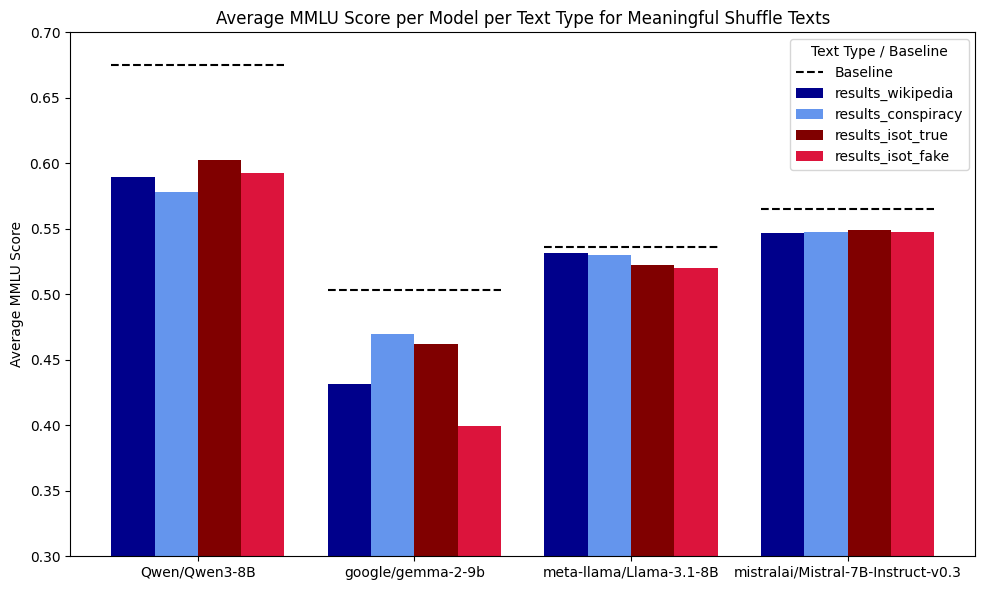

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

csv_files = ["results_wikipedia.csv", "results_conspiracy.csv", "results_isot_true.csv", "results_isot_fake.csv"]
dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    df = df[df['context_type'] == 'meani']

    text_type = file.replace(".csv", "")
    df['text_type'] = text_type
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
order = [
    "results_wikipedia",
    "results_conspiracy",
    "results_isot_true",
    "results_isot_fake"
]
color_list = {
    "results_wikipedia": 'darkblue',
    "results_conspiracy": 'cornflowerblue',
    "results_isot_true": 'maroon',
    "results_isot_fake": 'crimson'
}
avg_scores = data.groupby(['model_name', 'text_type'])['accuracy'].mean().unstack()
avg_scores = avg_scores[order]

fig, ax = plt.subplots(figsize=(10,6))

models = avg_scores.index
x = range(len(models))
width = 0.2  

for i, text_type in enumerate(avg_scores.columns):
    ax.bar([p + width*i for p in x], avg_scores[text_type], width, label=text_type, color=color_list[text_type])

ax.set_xticks([p + width*(len(avg_scores.columns)/2 - 0.5) for p in x])
ax.set_xticklabels(models)
ax.set_ylabel("Average MMLU Score")
ax.set_title("Average MMLU Score per Model per Text Type for Meaningful Shuffle Texts")
plt.ylim((0.3,0.7))  

baseline = {
    "meta-llama/Llama-3.1-8B": 0.536,
    "google/gemma-2-9b": 0.503,
    "Qwen/Qwen3-8B": 0.675,
    "mistralai/Mistral-7B-Instruct-v0.3": 0.565
}

line_width = 0.80
for i, model in enumerate(models):
    group_center = i + width*(len(avg_scores.columns)/2 - 0.5)
    label = "Baseline" if i == 0 else "_nolegend_"
    ax.hlines(y=baseline[model],
              xmin=group_center - line_width/2,
              xmax=group_center + line_width/2,
              colors='black',
              linestyles='dashed',
              label=label)

ax.legend(title="Text Type / Baseline")
plt.tight_layout()
plt.show()


content_type
Wikipedia     0.000669
Conspiracy    0.000816
True News     0.000470
Fake News     0.000470
Name: accuracy, dtype: float64


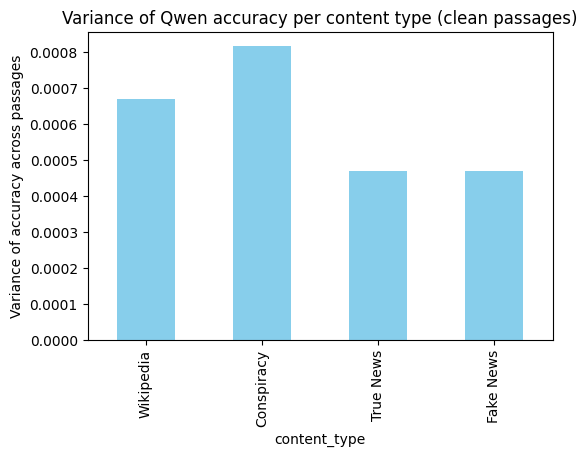

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
wiki = pd.read_csv("results_wikipedia.csv")
cons = pd.read_csv("results_conspiracy.csv")
true_news = pd.read_csv("results_isot_true.csv")
fake_news = pd.read_csv("results_isot_fake.csv")

# Keep only Qwen and clean context
dfs = []
for df, name in zip([wiki, cons, true_news, fake_news],
                    ["Wikipedia", "Conspiracy", "True News", "Fake News"]):
    df = df[df["model_name"].str.contains("Qwen")]
    df = df[df["context_type"] == "clean"].copy()
    df["content_type"] = name
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Compute variance of accuracy across passages
var_by_content = df_all.groupby("content_type")["accuracy"].var()

# Reorder to desired order
var_by_content = var_by_content.reindex(["Wikipedia", "Conspiracy", "True News", "Fake News"])

print(var_by_content)

# Simple bar plot
plt.figure(figsize=(6,4))
var_by_content.plot(kind="bar", color="skyblue")
plt.ylabel("Variance of accuracy across passages")
plt.title("Variance of Qwen accuracy per content type (clean passages)")
plt.show()


content_type
Wikipedia     0.000106
Conspiracy    0.000147
True News     0.000147
Fake News     0.000302
Name: accuracy, dtype: float64


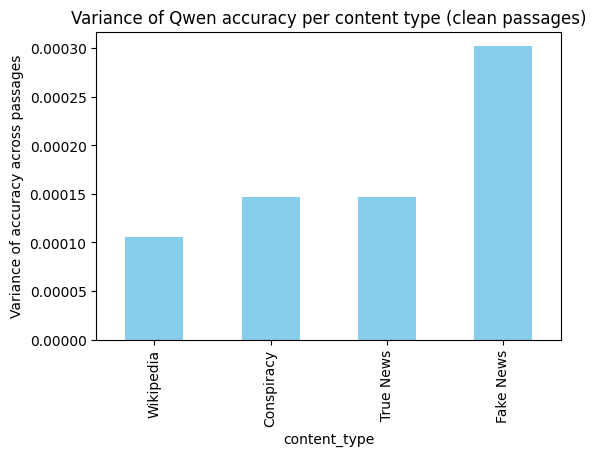

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
wiki = pd.read_csv("results_wikipedia.csv")
cons = pd.read_csv("results_conspiracy.csv")
true_news = pd.read_csv("results_isot_true_temporally.csv")
fake_news = pd.read_csv("results_isot_fake.csv")

# Keep only Qwen and clean context
dfs = []
for df, name in zip([wiki, cons, true_news, fake_news],
                    ["Wikipedia", "Conspiracy", "True News", "Fake News"]):
    df = df[df["model_name"].str.contains("llama")]
    df = df[df["context_type"] == "clean"].copy()
    df["content_type"] = name
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Compute variance of accuracy across passages
var_by_content = df_all.groupby("content_type")["accuracy"].var()

# Reorder to desired order
var_by_content = var_by_content.reindex(["Wikipedia", "Conspiracy", "True News", "Fake News"])

print(var_by_content)

# Simple bar plot
plt.figure(figsize=(6,4))
var_by_content.plot(kind="bar", color="skyblue")
plt.ylabel("Variance of accuracy across passages")
plt.title("Variance of Qwen accuracy per content type (clean passages)")
plt.show()


content_type
Wikipedia     0.000046
Conspiracy    0.000063
True News     0.000053
Fake News     0.000053
Name: accuracy, dtype: float64


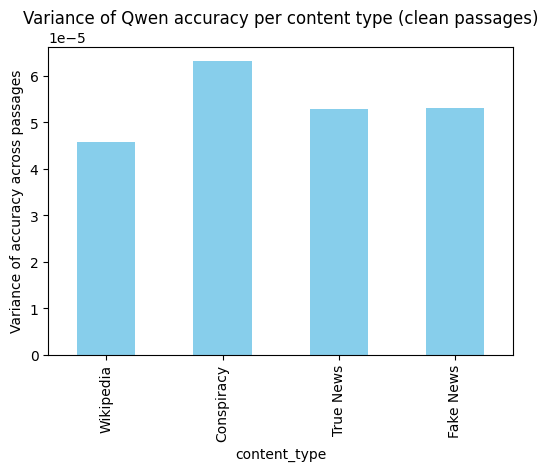

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
wiki = pd.read_csv("results_wikipedia.csv")
cons = pd.read_csv("results_conspiracy.csv")
true_news = pd.read_csv("results_isot_true.csv")
fake_news = pd.read_csv("results_isot_fake.csv")

# Keep only Qwen and clean context
dfs = []
for df, name in zip([wiki, cons, true_news, fake_news],
                    ["Wikipedia", "Conspiracy", "True News", "Fake News"]):
    df = df[df["model_name"].str.contains("mistral")]
    df = df[df["context_type"] == "clean"].copy()
    df["content_type"] = name
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Compute variance of accuracy across passages
var_by_content = df_all.groupby("content_type")["accuracy"].var()

# Reorder to desired order
var_by_content = var_by_content.reindex(["Wikipedia", "Conspiracy", "True News", "Fake News"])

print(var_by_content)

# Simple bar plot
plt.figure(figsize=(6,4))
var_by_content.plot(kind="bar", color="skyblue")
plt.ylabel("Variance of accuracy across passages")
plt.title("Variance of Qwen accuracy per content type (clean passages)")
plt.show()


content_type
Wikipedia     0.006387
Conspiracy    0.004189
True News     0.004960
Fake News     0.004960
Name: accuracy, dtype: float64


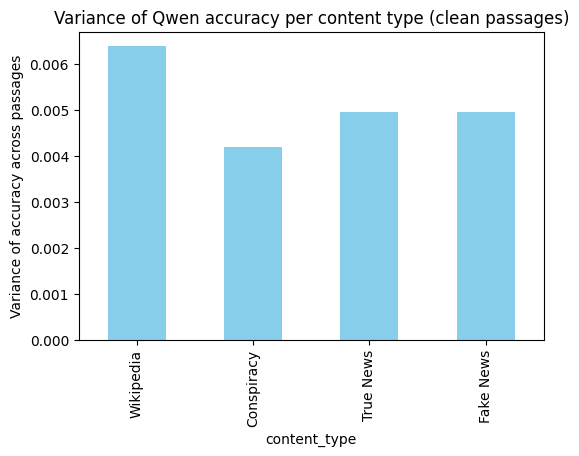

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
wiki = pd.read_csv("results_wikipedia.csv")
cons = pd.read_csv("results_conspiracy.csv")
true_news = pd.read_csv("results_isot_true.csv")
fake_news = pd.read_csv("results_isot_fake.csv")

# Keep only Qwen and clean context
dfs = []
for df, name in zip([wiki, cons, true_news, fake_news],
                    ["Wikipedia", "Conspiracy", "True News", "Fake News"]):
    df = df[df["model_name"].str.contains("gemma")]
    df = df[df["context_type"] == "clean"].copy()
    df["content_type"] = name
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Compute variance of accuracy across passages
var_by_content = df_all.groupby("content_type")["accuracy"].var()

# Reorder to desired order
var_by_content = var_by_content.reindex(["Wikipedia", "Conspiracy", "True News", "Fake News"])

print(var_by_content)

# Simple bar plot
plt.figure(figsize=(6,4))
var_by_content.plot(kind="bar", color="skyblue")
plt.ylabel("Variance of accuracy across passages")
plt.title("Variance of Qwen accuracy per content type (clean passages)")
plt.show()


content_type
Wikipedia     0.001802
Conspiracy    0.001304
True News     0.000418
Fake News     0.001446
Name: accuracy, dtype: float64


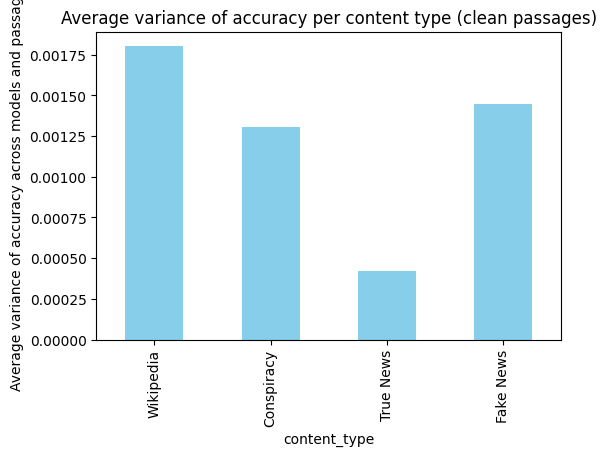

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
wiki = pd.read_csv("results_wikipedia.csv")
cons = pd.read_csv("results_conspiracy.csv")
true_news = pd.read_csv("results_isot_true_temporally.csv")
fake_news = pd.read_csv("results_isot_fake.csv")

# Keep only clean context
dfs = []
for df, name in zip([wiki, cons, true_news, fake_news],
                    ["Wikipedia", "Conspiracy", "True News", "Fake News"]):
    df = df[df["context_type"] == "clean"].copy()
    df["content_type"] = name
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Compute variance of accuracy per model and content type
var_per_model = df_all.groupby(["content_type", "model_name"])["accuracy"].var().reset_index()

# Then average variance across models for each content type
var_avg = var_per_model.groupby("content_type")["accuracy"].mean()

# Reorder for plotting
var_avg = var_avg.reindex(["Wikipedia", "Conspiracy", "True News", "Fake News"])

print(var_avg)

# Plot
plt.figure(figsize=(6,4))
var_avg.plot(kind="bar", color="skyblue")
plt.ylabel("Average variance of accuracy across models and passages")
plt.title("Average variance of accuracy per content type (clean passages)")
plt.show()


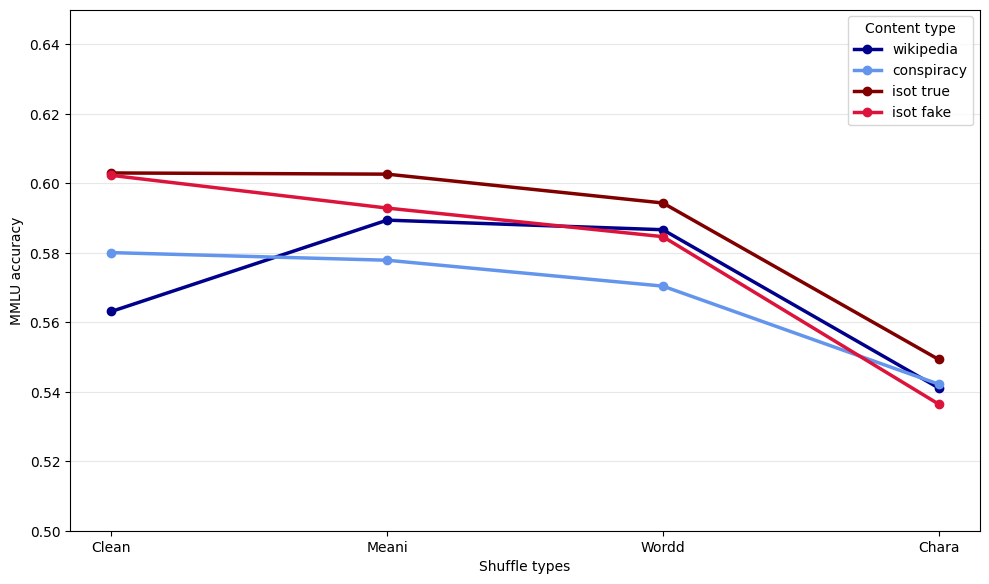

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

csv_files = [
    "results_wikipedia.csv",
    "results_conspiracy.csv",
    "results_isot_true.csv",
    "results_isot_fake.csv"
]

dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    df = df[df['model_name'] == 'Qwen/Qwen3-8B']
    df['text_type'] = file.replace(".csv", "")
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

order = [
    "results_wikipedia",
    "results_conspiracy",
    "results_isot_true",
    "results_isot_fake"
]

context_order = ["clean", "meani", "wordd", "chara"]

base_colors = {
    "results_wikipedia": 'darkblue',
    "results_conspiracy": 'cornflowerblue',
    "results_isot_true": 'maroon',
    "results_isot_fake": 'crimson'
}

avg_scores = (
    data
    .groupby(['text_type', 'context_type'])['accuracy']
    .mean()
    .unstack()
    .loc[order, context_order]
)

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(context_order))

for text_type in order:
    ax.plot(
        x,
        avg_scores.loc[text_type],
        marker='o',
        linewidth=2.5,
        color=base_colors[text_type],
        label=text_type.replace("results_", "").replace("_", " ")
    )

ax.set_xticks(x)
ax.set_xticklabels(["Clean", "Meani", "Wordd", "Chara"])

ax.set_ylabel("MMLU accuracy")
ax.set_xlabel("Shuffle types")

ax.set_ylim(0.3, 0.65)
ax.legend(title="Content type")

ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.ylim((0.5, 0.65))
plt.show()
